# Laboratorio 5.3: Clasificación con PyTorch (CIFAR-10)

**Dataset:** CIFAR-10  

| Concepto | Archivo fuente |
|---|---|
| `nn.Sequential`, `nn.Module`, optimizadores, capas | `02-pytorch_nn.ipynb` |
| Iteración de tensores, batches, `Dataset`, `DataLoader`, `collate_fn` | `03-pytorch_datasets.ipynb` |
| `state_dict`, modelo completo, best-model checkpoint, TorchScript, ONNX | `04-pytorch_save.ipynb` |
| **Resume-from-checkpoint** (backup del entrenamiento) | `04-pytorch_save.ipynb` *(mencionado explícitamente)* + `03-pytorch_datasets.ipynb` *(implementado parcialmente)* |

---
# Secciones Obligatorias PyTorch

## 1. Modelos Secuenciales
> 📁 Concepto de `02-pytorch_nn.ipynb`

`nn.Sequential` encadena capas en orden. Útil para arquitecturas sin bifurcaciones.

In [1]:
import torch
from torch import nn
import numpy as np

# MLP secuencial para CIFAR-10 (02-pytorch_nn.ipynb — "Modelos secuenciales")
D_in, H1, H2, D_out = 3072, 512, 128, 10

modelo_secuencial = nn.Sequential(
    nn.Linear(D_in, H1),
    nn.ReLU(),
    nn.Linear(H1, H2),
    nn.ReLU(),
    nn.Linear(H2, D_out),
)
print(modelo_secuencial)

x_demo = torch.randn(8, 3072)
out = modelo_secuencial(x_demo)
print(f"Input: {x_demo.shape}  →  Output: {out.shape}")

Sequential(
  (0): Linear(in_features=3072, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)
Input: torch.Size([8, 3072])  →  Output: torch.Size([8, 10])


## 2. Optimizadores y Funciones de Pérdida
> 📁 Concepto de `02-pytorch_nn.ipynb`

`CrossEntropyLoss` + `Adam`. El loop: forward → loss → `zero_grad` → `backward` → `step`.

In [2]:
# (02-pytorch_nn.ipynb — "Optimizadores y Funciones de pérdida")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelo_secuencial.parameters(), lr=1e-3)

x_demo = torch.randn(16, 3072)
y_demo = torch.randint(0, 10, (16,))

logits = modelo_secuencial(x_demo)
loss   = criterion(logits, y_demo)
optimizer.zero_grad()
loss.backward()
optimizer.step()

acc = (logits.argmax(1) == y_demo).float().mean().item()
print(f"Loss: {loss.item():.4f} | Acc: {acc:.4f}")

Loss: 2.3267 | Acc: 0.0000


## 3. Modelos Custom con `nn.Module`
> 📁 Concepto de `02-pytorch_nn.ipynb`

Heredando de `nn.Module` podemos añadir `BatchNorm`, `Dropout` y cualquier lógica especial en `forward`.

In [3]:
# (02-pytorch_nn.ipynb — "Modelos custom con nn.Module")
class MLP_CIFAR10(nn.Module):
    """MLP con BatchNorm y Dropout para CIFAR-10."""
    def __init__(self, in_features=3072, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(in_features, 1024)
        self.bn1   = nn.BatchNorm1d(1024)
        self.act1  = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.fc2   = nn.Linear(1024, 512)
        self.bn2   = nn.BatchNorm1d(512)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.fc3   = nn.Linear(512, 256)
        self.act3  = nn.ReLU()
        self.out   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.drop1(self.act1(self.bn1(self.fc1(x))))
        x = self.drop2(self.act2(self.bn2(self.fc2(x))))
        x = self.act3(self.fc3(x))
        return self.out(x)

model_demo = MLP_CIFAR10()
total_params = sum(p.numel() for p in model_demo.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")
print(model_demo)

Parámetros entrenables: 3,808,522
MLP_CIFAR10(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (act3): ReLU()
  (out): Linear(in_features=256, out_features=10, bias=True)
)


## 4. Accediendo a las Capas
> 📁 Concepto de `02-pytorch_nn.ipynb`

In [4]:
# (02-pytorch_nn.ipynb — "Accediendo a las capas de una red")
print("Pesos fc1:", model_demo.fc1.weight.shape)
print("Bias  fc1:", model_demo.fc1.bias.shape)

for name, param in model_demo.named_parameters():
    print(f"  {name:25s} → {tuple(param.shape)}")

Pesos fc1: torch.Size([1024, 3072])
Bias  fc1: torch.Size([1024])
  fc1.weight                → (1024, 3072)
  fc1.bias                  → (1024,)
  bn1.weight                → (1024,)
  bn1.bias                  → (1024,)
  fc2.weight                → (512, 1024)
  fc2.bias                  → (512,)
  bn2.weight                → (512,)
  bn2.bias                  → (512,)
  fc3.weight                → (256, 512)
  fc3.bias                  → (256,)
  out.weight                → (10, 256)
  out.bias                  → (10,)


## 5. Iterando Tensores
> 📁 Concepto de `03-pytorch_datasets.ipynb`

In [5]:
# (03-pytorch_datasets.ipynb — "Iterando tensores")
X_tensor = torch.randn(5, 3072)
for i in range(len(X_tensor)):
    muestra = X_tensor[i]
print(f"Última muestra shape: {muestra.shape}")

Última muestra shape: torch.Size([3072])


## 6. Iterando por Batches
> 📁 Concepto de `03-pytorch_datasets.ipynb`

In [6]:
# (03-pytorch_datasets.ipynb — "Iterando por Batches")
batch_size = 2
for i in range(0, len(X_tensor), batch_size):
    batch = X_tensor[i:i+batch_size]
    print(f"  batch[{i}:{i+batch_size}] → shape {batch.shape}")

  batch[0:2] → shape torch.Size([2, 3072])
  batch[2:4] → shape torch.Size([2, 3072])
  batch[4:6] → shape torch.Size([1, 3072])


## 7. La Clase `Dataset`
> 📁 Concepto de `03-pytorch_datasets.ipynb`

Hereda de `torch.utils.data.Dataset`. Obligatorio: `__init__`, `__len__`, `__getitem__`.

In [7]:
# (03-pytorch_datasets.ipynb — "La clase Dataset")
from torch.utils.data import Dataset, DataLoader

class CIFAR10Dataset(Dataset):
    """Dataset personalizado para CIFAR-10 con normalización media/std."""
    def __init__(self, X, y, mean=None, std=None):
        if mean is None: mean = X.mean(axis=0)
        if std  is None: std  = X.std(axis=0) + 1e-8
        X_norm    = (X - mean) / std
        self.X    = torch.tensor(X_norm, dtype=torch.float32)
        self.y    = torch.tensor(y,      dtype=torch.long)
        self.mean = mean
        self.std  = std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Demo
X_fake = np.random.rand(100, 3072).astype(np.float32)
y_fake = np.random.randint(0, 10, 100)
ds_demo = CIFAR10Dataset(X_fake, y_fake)
print(f"Len: {len(ds_demo)} | X[0]: {ds_demo[0][0].shape} | y[0]: {ds_demo[0][1].item()}")

Len: 100 | X[0]: torch.Size([3072]) | y[0]: 8


## 8. La Clase `DataLoader`
> 📁 Concepto de `03-pytorch_datasets.ipynb`

Gestiona batches, shuffle automático y `collate_fn` personalizado.

In [8]:
# (03-pytorch_datasets.ipynb — "La clase DataLoader")
dataloader_demo = DataLoader(ds_demo, batch_size=16, shuffle=True)
x_batch, y_batch = next(iter(dataloader_demo))
print(f"Batch X: {x_batch.shape} | Batch y: {y_batch.shape}")

# collate_fn personalizado (03-pytorch_datasets.ipynb)
def collate_fn(batch):
    xs = torch.stack([x for x, y in batch])
    ys = torch.stack([y for x, y in batch])
    return xs, ys

dl_custom = DataLoader(ds_demo, batch_size=16, shuffle=True, collate_fn=collate_fn)
xb, yb = next(iter(dl_custom))
print(f"Con collate_fn → X: {xb.shape}, y: {yb.shape}")

Batch X: torch.Size([16, 3072]) | Batch y: torch.Size([16])
Con collate_fn → X: torch.Size([16, 3072]), y: torch.Size([16])


## 9. Guardando Modelos
> 📁 Concepto de `04-pytorch_save.ipynb`

### 9.1 Guardar y cargar `state_dict` (recomendado)
Solo se guardan los pesos. Al cargar necesitas tener la clase del modelo definida.

In [9]:
# (04-pytorch_save.ipynb — "Guardando los parámetros")
import os
os.makedirs('./checkpoints', exist_ok=True)

PATH = './checkpoints/mlp_demo.pth'
torch.save(model_demo.state_dict(), PATH)
print(f"Guardado: {PATH}")

model_cargado = MLP_CIFAR10()
model_cargado.load_state_dict(torch.load(PATH, weights_only=True))
model_cargado.eval()
print("Cargado correctamente ✓")

Guardado: ./checkpoints/mlp_demo.pth
Cargado correctamente ✓


### 9.2 Guardar el modelo completo
Incluye arquitectura + pesos. Más flexible, pero necesitas la clase igualmente.

In [10]:
# (04-pytorch_save.ipynb — guardar modelo entero)
torch.save(model_demo, './checkpoints/mlp_demo_completo.pt')
model_full = torch.load('./checkpoints/mlp_demo_completo.pt', weights_only=False)
model_full.eval()
print("Modelo completo cargado ✓")

Modelo completo cargado ✓


### 9.3 Best-Model Checkpoint (guardar si mejora val_acc)
> 📁 Concepto de `04-pytorch_save.ipynb`

En la función `fit()` del archivo original: *"guardar modelo si es el mejor"* y *"cargar el mejor modelo al final del entrenamiento"*.

### 9.4 ⚡ Resume-from-Checkpoint (Backup del Entrenamiento)
> 📁 Concepto mencionado en `04-pytorch_save.ipynb` y presente en `03-pytorch_datasets.ipynb`

**El archivo `04-pytorch_save.ipynb` dice explícitamente:**
> *"Esta opción es ideal para guardar y cargar modelos durante el entrenamiento del mismo, **quizás incluso junto al estado del optimizador**, de manera que podemos entrenar modelos a partir de estos **checkpoints** en lugar de empezar de **cero** cada vez."*

**El archivo `03-pytorch_datasets.ipynb` implementa (parcialmente) el intento de reanudar entrenamiento cargando `state_dict` antes de continuar entrenando.**

La versión completa (backup real) guarda **todo lo necesario para reanudar exactamente donde se paró**: época actual, pesos del modelo, estado del optimizador, estado del scheduler e historial de métricas.

```
checkpoint = {
    'epoch':           epoch,
    'model_state':     model.state_dict(),       ← pesos
    'optimizer_state': optimizer.state_dict(),   ← momentum, lr adaptivo
    'scheduler_state': scheduler.state_dict(),   ← lr schedule
    'history':         history,                  ← curvas de entrenamiento
    'best_val_acc':    best_val_acc,              ← mejor métrica
}
torch.save(checkpoint, PATH)
```

Sin el estado del optimizador (Adam guarda momentum y varianzas por parámetro), el entrenamiento **no continúa de forma idéntica** aunque se carguen los pesos.

In [11]:
# ── Función fit() completa con DUAL checkpoint ──────────────────────────────
# 1) BACKUP cada N épocas  → para reanudar si se interrumpe el entrenamiento
# 2) BEST MODEL            → guarda solo cuando mejora val_accuracy
# ─────────────────────────────────────────────────────────────────────────────

def fit(model, train_loader, val_loader,
        epochs=5, lr=1e-3,
        best_path='./checkpoints/best_model.pth',
        resume_path='./checkpoints/resume_checkpoint.pth',
        backup_every=5,       # guardar backup cada N épocas
        device='cpu'):
    """
    Loop de entrenamiento con:
    - Adam + StepLR
    - Best-model checkpoint  (04-pytorch_save.ipynb)
    - Resume-from-checkpoint (04-pytorch_save.ipynb + 03-pytorch_datasets.ipynb)
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    start_epoch  = 1
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # ── Reanudar desde backup si existe ──────────────────────────────────────
    if os.path.exists(resume_path):
        print(f"▶ Reanudando entrenamiento desde: {resume_path}")
        ckpt = torch.load(resume_path, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        history      = ckpt['history']
        print(f"  → Continuando desde época {start_epoch} | mejor val_acc hasta ahora: {best_val_acc:.2f}%")
    else:
        print("▶ Entrenamiento desde cero.")

    for epoch in range(start_epoch, epochs + 1):
        # ── Entrenamiento ────────────────────────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = nn.CrossEntropyLoss()(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * xb.size(0)
            train_correct += (logits.argmax(1) == yb).sum().item()
            train_total   += yb.size(0)
        scheduler.step()

        # ── Validación ────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits  = model(xb)
                loss    = nn.CrossEntropyLoss()(logits, yb)
                val_loss    += loss.item() * xb.size(0)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total   += yb.size(0)

        t_loss = train_loss / train_total
        t_acc  = train_correct / train_total * 100
        v_loss = val_loss / val_total
        v_acc  = val_correct / val_total * 100
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        # ── [A] BEST MODEL: guardar solo si mejora ────────────────────────────
        # (04-pytorch_save.ipynb — "guardar modelo si es el mejor")
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), best_path)
            print(f"  ✓ Mejor modelo guardado (val_acc={v_acc:.2f}%)")

        # ── [B] BACKUP/RESUME: guardar estado completo cada N épocas ─────────
        # (04-pytorch_save.ipynb: "junto al estado del optimizador")
        # (03-pytorch_datasets.ipynb: carga state_dict para reanudar)
        if epoch % backup_every == 0:
            checkpoint = {
                'epoch':           epoch,
                'model_state':     model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'history':         history,
                'best_val_acc':    best_val_acc,
            }
            torch.save(checkpoint, resume_path)
            print(f"  💾 Backup guardado (época {epoch}/{epochs})")

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"loss={t_loss:.4f} acc={t_acc:.2f}% | "
              f"val_loss={v_loss:.4f} val_acc={v_acc:.2f}%")

    # ── Cargar el mejor modelo al final ──────────────────────────────────────
    # (04-pytorch_save.ipynb — "cargar el mejor modelo al final del entrenamiento")
    model.load_state_dict(torch.load(best_path, weights_only=True))
    print(f"\n✅ Entrenamiento finalizado. Mejor val_acc: {best_val_acc:.2f}%")
    return history

print("Función fit() con dual-checkpoint definida ✓")

Función fit() con dual-checkpoint definida ✓


### Cómo Reanudar el Entrenamiento (ejemplo práctico)

Si el entrenamiento se interrumpe en la época 30 (de 50), simplemente **vuelves a ejecutar la misma celda** `fit(...)`. La función detecta automáticamente el archivo `resume_checkpoint.pth` y continúa desde la época 31.

```
# Primera ejecución (entrena épocas 1-50, guardando backup cada 5)
history = fit(model, train_loader, val_loader, epochs=50, ...)

# Si se interrumpió en época 30 y quieres continuar:
# Solo vuelve a ejecutar la misma línea — arranca desde época 31
history = fit(model, train_loader, val_loader, epochs=50, ...)
```

> ⚠️ Para empezar desde cero (ignorar backup): elimina el archivo `resume_checkpoint.pth` o pasa `resume_path=None`.

### 9.5 Exportar: TorchScript y ONNX
> 📁 Concepto de `04-pytorch_save.ipynb`

In [12]:
# (04-pytorch_save.ipynb — "Exportando modelos / Torchscript")
example_input = torch.randn(1, 3072)

# tracing (más eficiente, no captura control flow)
traced  = torch.jit.trace(model_demo.cpu().eval(), example_input)
traced.save('./checkpoints/mlp_traced.pt')

# scripting (más flexible, captura ramificaciones)
scripted = torch.jit.script(model_demo.cpu().eval())
scripted.save('./checkpoints/mlp_scripted.pt')

loaded = torch.jit.load('./checkpoints/mlp_traced.pt')
print("TorchScript trace  cargado ✓ →", loaded(example_input).shape)

loaded2 = torch.jit.load('./checkpoints/mlp_scripted.pt')
print("TorchScript script cargado ✓ →", loaded2(example_input).shape)

TorchScript trace  cargado ✓ → torch.Size([1, 10])
TorchScript script cargado ✓ → torch.Size([1, 10])


In [13]:
# (04-pytorch_save.ipynb — "ONNX")
# Descomentar si tienes onnx + onnxruntime instalados
# torch.onnx.export(
#     model_demo.cpu().eval(), example_input,
#     './checkpoints/mlp.onnx',
#     input_names=['input'], output_names=['logits'], opset_version=11
# )
# print("ONNX exportado ✓")

---
# Trabajo Real: CIFAR-10

## Fase 1: Carga y Preprocesamiento del Dataset

In [14]:
import pickle
import matplotlib.pyplot as plt
%matplotlib inline

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

meta           = unpickle(ruta_cifar + 'batches.meta')
nombres_clases = [n.decode('utf-8') for n in meta[b'label_names']]
print("Clases:", nombres_clases)

X_train_list, y_train_list = [], []
for i in range(1, 6):
    batch = unpickle(f'{ruta_cifar}data_batch_{i}')
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list).astype(np.float32)
y_train = np.array(y_train_list, dtype=np.int64)

test_batch = unpickle(ruta_cifar + 'test_batch')
X_test  = test_batch[b'data'].astype(np.float32)
y_test  = np.array(test_batch[b'labels'], dtype=np.int64)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipykernel_1270452/3676225285.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fo, encoding='bytes')


Train: (50000, 3072) | Test: (10000, 3072)


### Visualización de muestras

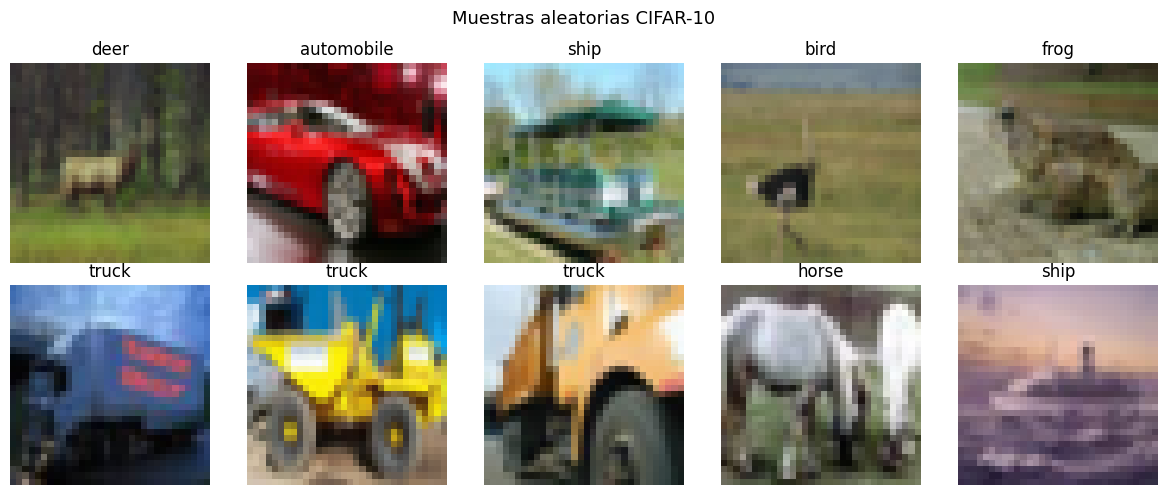

In [15]:
rng = np.random.default_rng(42)
indices = rng.choice(len(X_train), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), indices):
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(nombres_clases[y_train[idx]])
    ax.axis('off')
plt.suptitle("Muestras aleatorias CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()

## Fase 2: Dataset, Modelo y Entrenamiento

### 2.1 Split Estratificado Train / Validación

In [16]:
rng2 = np.random.default_rng(42)
idx_tr, idx_val = [], []
for c in range(10):
    idx_c = rng2.permutation(np.where(y_train == c)[0])
    n_val = int(len(idx_c) * 0.2)
    idx_val.append(idx_c[:n_val])
    idx_tr.append(idx_c[n_val:])

idx_tr  = np.concatenate(idx_tr);  rng2.shuffle(idx_tr)
idx_val = np.concatenate(idx_val); rng2.shuffle(idx_val)

X_tr, y_tr   = X_train[idx_tr]  / 255.0, y_train[idx_tr]
X_val, y_val = X_train[idx_val] / 255.0, y_train[idx_val]
X_te         = X_test / 255.0

mean_tr = X_tr.mean(axis=0)
std_tr  = X_tr.std(axis=0) + 1e-8
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_te.shape}")

Train: (40000, 3072) | Val: (10000, 3072) | Test: (10000, 3072)


### 2.2 Datasets y DataLoaders

In [17]:
BATCH_SIZE = 256

train_ds = CIFAR10Dataset(X_tr,  y_tr,  mean=mean_tr, std=std_tr)
val_ds   = CIFAR10Dataset(X_val, y_val, mean=mean_tr, std=std_tr)
test_ds  = CIFAR10Dataset(X_te,  y_test, mean=mean_tr, std=std_tr)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches/epoch → train: {len(train_loader)} | val: {len(val_loader)}")

Batches/epoch → train: 157 | val: 40


### 2.3 Modelo y Dispositivo

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

model = MLP_CIFAR10(in_features=3072, num_classes=10)
print(f"Parámetros: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Dispositivo: cuda
Parámetros: 3,808,522


### 2.4 Entrenamiento con Dual Checkpoint

- **backup_every=5**: guarda un checkpoint de recuperación cada 5 épocas (modelo + optimizador + scheduler + historial)
- **best_path**: guarda el mejor modelo cuando mejora `val_accuracy`
- Si el entrenamiento se interrumpe, **ejecuta esta celda de nuevo** — continuará desde el último backup

In [19]:
EPOCHS       = 50
BEST_PATH    = './checkpoints/best_cifar10.pth'
RESUME_PATH  = './checkpoints/resume_checkpoint.pth'

history = fit(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    lr           = 1e-3,
    best_path    = BEST_PATH,
    resume_path  = RESUME_PATH,
    backup_every = 5,
    device       = device
)

▶ Entrenamiento desde cero.
  ✓ Mejor modelo guardado (val_acc=44.58%)
Epoch   1/50 | loss=1.6796 acc=39.57% | val_loss=1.5468 val_acc=44.58%
  ✓ Mejor modelo guardado (val_acc=49.16%)
Epoch   2/50 | loss=1.4806 acc=47.02% | val_loss=1.4257 val_acc=49.16%
  ✓ Mejor modelo guardado (val_acc=51.44%)
Epoch   3/50 | loss=1.3948 acc=50.21% | val_loss=1.3715 val_acc=51.44%
Epoch   4/50 | loss=1.3308 acc=52.56% | val_loss=1.3767 val_acc=50.80%
  ✓ Mejor modelo guardado (val_acc=52.67%)
  💾 Backup guardado (época 5/50)
Epoch   5/50 | loss=1.2857 acc=54.14% | val_loss=1.3348 val_acc=52.67%
  ✓ Mejor modelo guardado (val_acc=52.96%)
Epoch   6/50 | loss=1.2440 acc=55.49% | val_loss=1.3215 val_acc=52.96%
  ✓ Mejor modelo guardado (val_acc=53.73%)
Epoch   7/50 | loss=1.2092 acc=56.75% | val_loss=1.3083 val_acc=53.73%
  ✓ Mejor modelo guardado (val_acc=54.79%)
Epoch   8/50 | loss=1.1724 acc=57.95% | val_loss=1.2711 val_acc=54.79%
Epoch   9/50 | loss=1.1509 acc=58.89% | val_loss=1.2737 val_acc=54.22%

### 2.5 Curvas de Entrenamiento

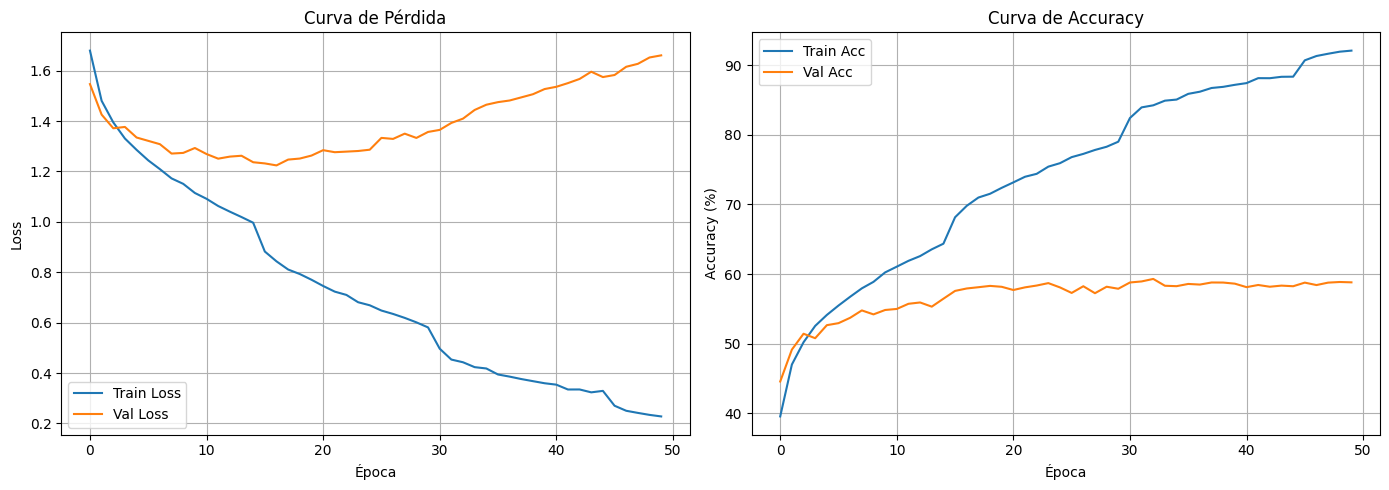

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Pérdida'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Curva de Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

## Fase 3: Evaluación en Test

Cargamos el **mejor modelo** (no el último) y evaluamos en las 10,000 imágenes de prueba.

In [21]:
best_model = MLP_CIFAR10(in_features=3072, num_classes=10)
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.to(device).eval()

correct, total = 0, 0
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds   = best_model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(yb.cpu().tolist())

test_acc = correct / total * 100
print(f"Test Accuracy (mejor modelo): {test_acc:.2f}%")

Test Accuracy (mejor modelo): 58.24%


### Matriz de Confusión

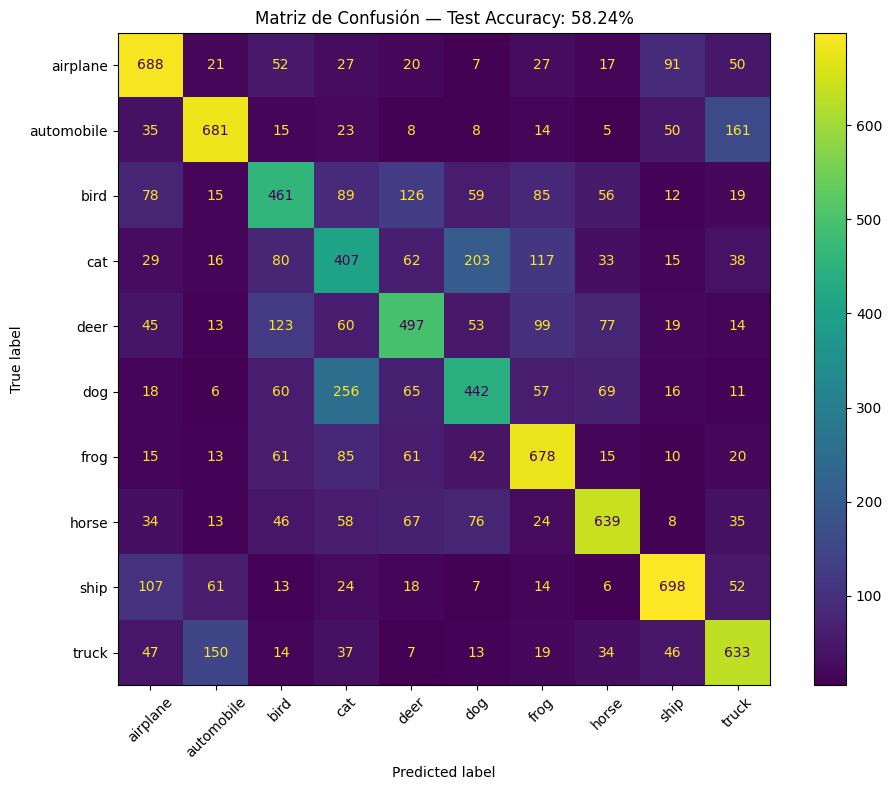

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=nombres_clases)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f"Matriz de Confusión — Test Accuracy: {test_acc:.2f}%")
plt.tight_layout(); plt.show()

### Accuracy por Clase

In [23]:
acc_por_clase = cm.diagonal() / cm.sum(axis=1) * 100
for nombre, acc in zip(nombres_clases, acc_por_clase):
    barra = '█' * int(acc / 5)
    print(f"  {nombre:12s}: {acc:5.2f}%  {barra}")

  airplane    : 68.80%  █████████████
  automobile  : 68.10%  █████████████
  bird        : 46.10%  █████████
  cat         : 40.70%  ████████
  deer        : 49.70%  █████████
  dog         : 44.20%  ████████
  frog        : 67.80%  █████████████
  horse       : 63.90%  ████████████
  ship        : 69.80%  █████████████
  truck       : 63.30%  ████████████


### Exportar Mejor Modelo (TorchScript para producción)

In [24]:
# (04-pytorch_save.ipynb — TorchScript del mejor modelo)
example_input  = torch.randn(1, 3072).cpu()
scripted_best  = torch.jit.trace(best_model.cpu().eval(), example_input)
scripted_best.save('./checkpoints/best_cifar10_scripted.pt')
print("Mejor modelo exportado como TorchScript ✓")

Mejor modelo exportado como TorchScript ✓


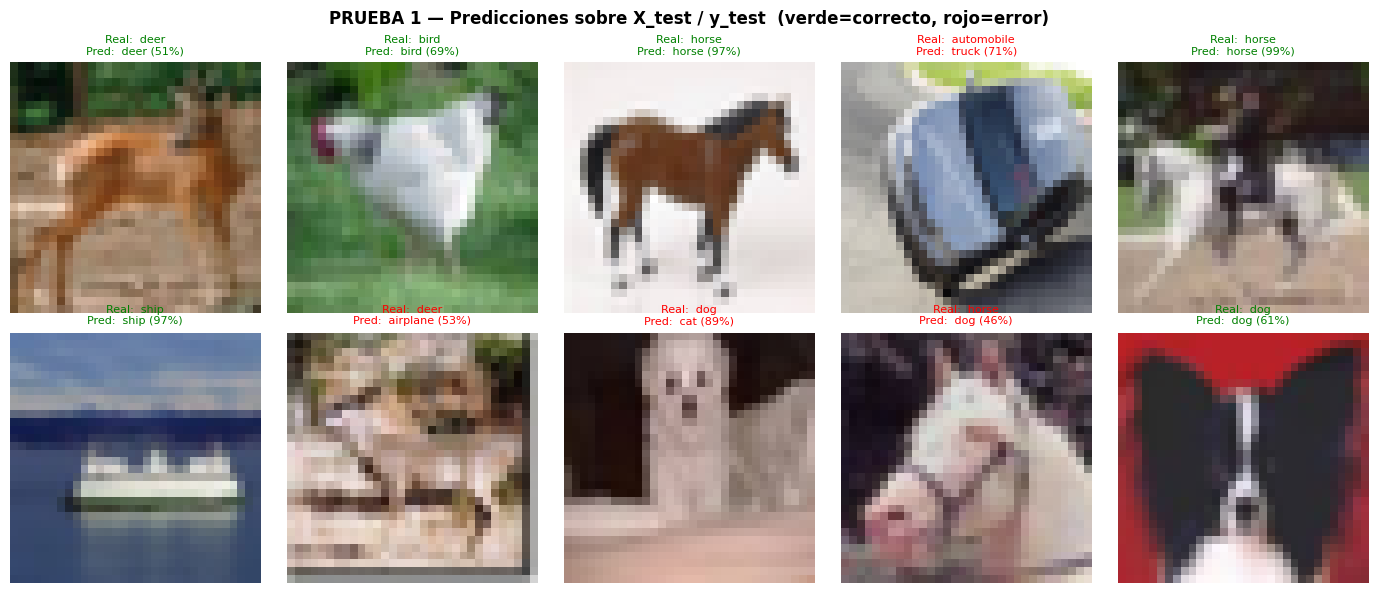

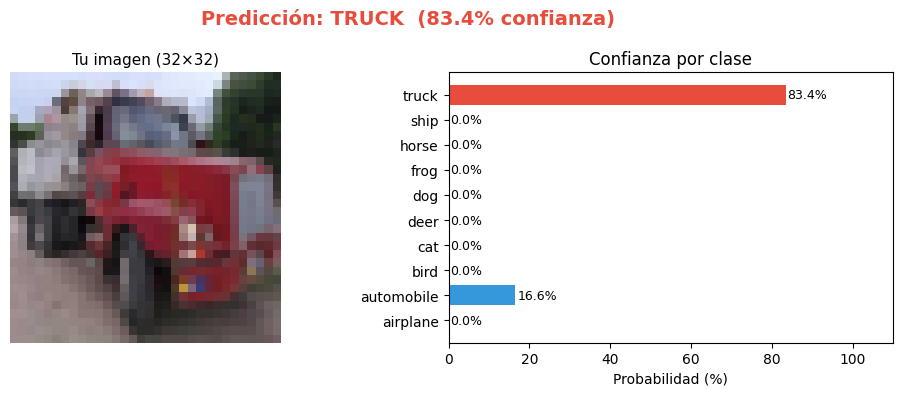


🔍 Predicción: TRUCK  (83.4%)

   Top 3:
   · truck         83.4%
   · automobile    16.6%
   · airplane      0.0%


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# PRUEBA 1: Predicción sobre muestras del conjunto de TEST (y_test aislado)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import torch
import numpy as np

# Cargar el mejor modelo
best_model = MLP_CIFAR10(in_features=3072, num_classes=10)
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
best_model.eval()

# Seleccionar 10 muestras aleatorias del test set
rng_prueba = np.random.default_rng(99)
idx_prueba = rng_prueba.choice(len(X_te), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flatten(), idx_prueba):
    # Imagen original (sin normalizar, solo /255)
    img = X_te[idx].reshape(3, 32, 32).transpose(1, 2, 0)

    # Preprocesar con la normalización del entrenamiento
    x_norm  = (X_te[idx] - mean_tr) / std_tr
    x_input = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0)

    # Predicción
    with torch.no_grad():
        probs      = torch.softmax(best_model(x_input), dim=1)[0]
        pred_idx   = probs.argmax().item()
        pred_nombre = nombres_clases[pred_idx]
        confianza   = probs[pred_idx].item() * 100

    real_nombre = nombres_clases[y_test[idx]]
    color_titulo = 'green' if pred_idx == y_test[idx] else 'red'

    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(
        f"Real:  {real_nombre}\nPred:  {pred_nombre} ({confianza:.0f}%)",
        fontsize=8, color=color_titulo
    )
    ax.axis('off')

plt.suptitle("PRUEBA 1 — Predicciones sobre X_test / y_test  (verde=correcto, rojo=error)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PRUEBA 2: Predicción sobre una imagen local de tu computadora
# ══════════════════════════════════════════════════════════════════════════════

from PIL import Image
import tkinter as tk
from tkinter import filedialog

# Abrir ventana para seleccionar archivo
root = tk.Tk()
root.withdraw()
ruta_imagen = filedialog.askopenfilename(
    title="Selecciona una imagen",
    filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp *.webp")]
)
root.destroy()

if not ruta_imagen:
    print("No se seleccionó ninguna imagen.")
else:
    # Preprocesamiento
    img_pil    = Image.open(ruta_imagen).convert('RGB').resize((32, 32))
    img_array  = np.array(img_pil, dtype=np.float32) / 255.0   # (32, 32, 3)
    img_flat   = img_array.transpose(2, 0, 1).flatten()         # (3072,)
    img_norm   = (img_flat - mean_tr) / std_tr
    x_input    = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0)

    # Predicción
    with torch.no_grad():
        probs        = torch.softmax(best_model(x_input), dim=1)[0]
        clase_idx    = probs.argmax().item()
        clase_nombre = nombres_clases[clase_idx]
        confianza    = probs[clase_idx].item() * 100

    # Mostrar resultado
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img_pil)
    axes[0].set_title(f"Tu imagen (32×32)", fontsize=11)
    axes[0].axis('off')

    colores = ['#e74c3c' if i == clase_idx else '#3498db' for i in range(10)]
    bars = axes[1].barh(nombres_clases, probs.numpy() * 100, color=colores)
    axes[1].set_xlabel('Probabilidad (%)')
    axes[1].set_title('Confianza por clase')
    axes[1].set_xlim(0, 110)
    for i, v in enumerate(probs.numpy() * 100):
        axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

    plt.suptitle(
        f'Predicción: {clase_nombre.upper()}  ({confianza:.1f}% confianza)',
        fontsize=14, fontweight='bold', color='#e74c3c'
    )
    plt.tight_layout()
    plt.show()

    print(f"\n🔍 Predicción: {clase_nombre.upper()}  ({confianza:.1f}%)")
    print(f"\n   Top 3:")
    for prob, idx in zip(*[x for x in [probs.topk(3).values, probs.topk(3).indices]]):
        print(f"   · {nombres_clases[idx.item()]:12s}  {prob.item()*100:.1f}%")